In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import circle_fitting as cf
import resonance_fitting as rf
import all_resonances as ar

In [21]:

file = "post-hole resonator/post_hole_room_temp.csv"
with open(file, "r") as f:
    lines = f.readlines()
start_idx = next(i for i, line in enumerate(lines) if line.strip().startswith("BEGIN CH1_DATA"))
df = pd.read_csv(file, skiprows=start_idx + 1)

print(df.head())


# force columns to numeric, coercing any stray text to NaN
df['S11(DB)'] = pd.to_numeric(df["S11(DB)"], errors="coerce")
df['S11(DEG)'] = pd.to_numeric(df["S11(DEG)"], errors="coerce")

# remove any rows that failed conversion (optional)
df = df.dropna(subset=["S11(DB)", "S11(DEG)"])

# now safe to compute
s11_mag = 10 ** (df["S11(DB)"] / 20)
s11_phase = np.deg2rad(df["S11(DEG)"])
s11_phase_unwrapped = np.unwrap(s11_phase)

s11_real = s11_mag * np.cos(s11_phase_unwrapped)
s11_imag = s11_mag * np.sin(s11_phase_unwrapped)

freq = pd.to_numeric(df["Freq(Hz)"], errors="coerce")
omega = 2 * np.pi * freq

tau = -np.gradient(s11_phase_unwrapped, omega)
df["tau_s"] = tau




          Freq(Hz)   S11(DB)   S11(DEG)  S11(DB).1  S11(DEG).1
0  6564841627.2357 -0.007221 -26.832602  -0.007221  -26.832602
1  6564867367.5397 -0.009445 -26.843567  -0.009445  -26.843567
2  6564893107.8437 -0.004601 -26.809219  -0.004601  -26.809219
3  6564918848.1477 -0.005090 -26.798929  -0.005090  -26.798929
4  6564944588.4517 -0.004472 -26.840605  -0.004472  -26.840605


In [22]:

s11_mag_lin = s11_mag
s11_phase = s11_phase % (2*np.pi)
s11_real = s11_mag_lin * np.cos(s11_phase)
s11_imag = s11_mag_lin * np.sin(s11_phase)
s11 = 1.0*s11_real + 1.0j*s11_imag
omega = 2 * np.pi * freq
s11_phase_unwrapped = np.unwrap(s11_phase)
dphi_domega = np.gradient(s11_phase_unwrapped, omega)
tau = 1e-9


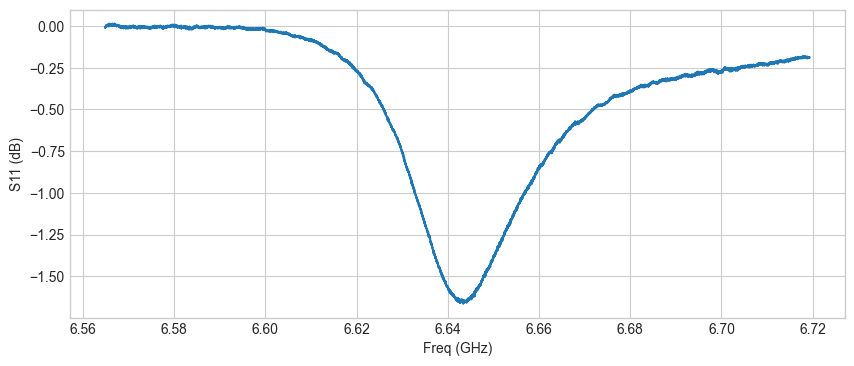

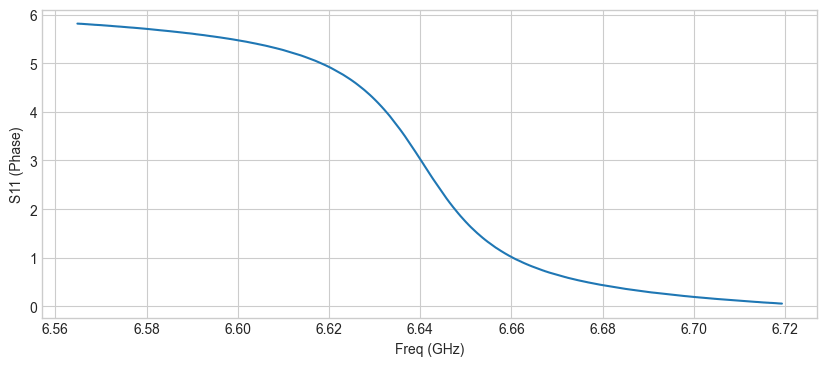

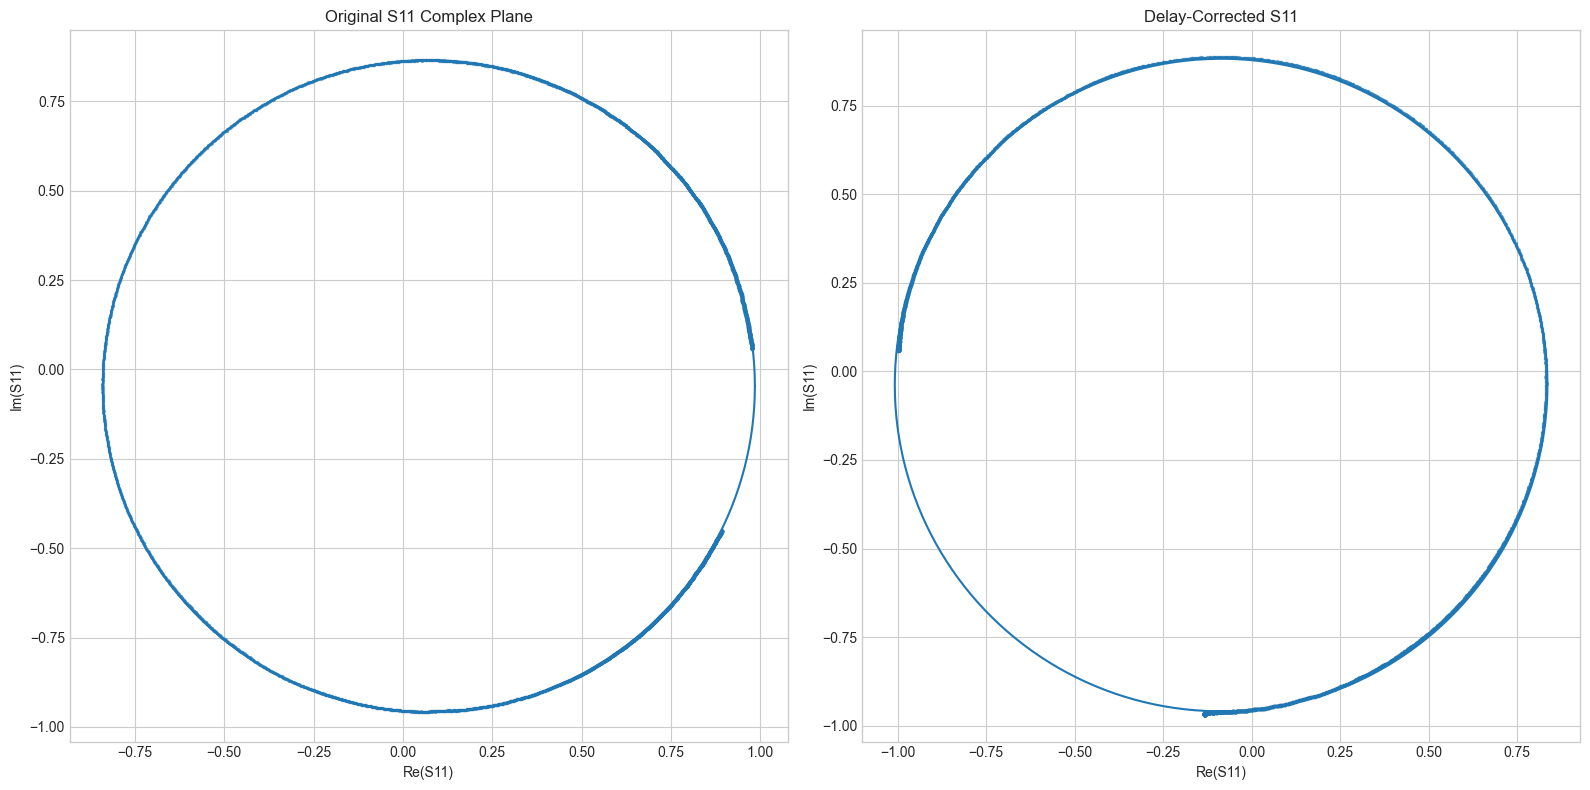


Original circle parameters:
Center: (0.073, -0.047), Radius: 0.912

Delay-corrected circle parameters:
Center: (-0.087, -0.038), Radius: 0.921


In [23]:
# Plot magnitude response
plt.figure(figsize=(10, 4))
plt.plot(freq/1e9, 20*np.log10(np.abs(s11)))
plt.ylabel("S11 (dB)")
plt.xlabel("Freq (GHz)")
plt.grid(True)
plt.show()

# Plot magnitude response
plt.figure(figsize=(10, 4))
plt.plot(freq/1e9, s11_phase)
plt.ylabel("S11 (Phase)")
plt.xlabel("Freq (GHz)")
plt.grid(True)
plt.show()

# Create figure with two subplots side by side
plt.figure(figsize=(16, 8))

# Original S11 data
plt.subplot(121)
plt.scatter(s11_real, s11_imag, s=2, alpha=0.5)
plt.xlabel('Re(S11)')
plt.ylabel('Im(S11)')
plt.grid(True)
plt.axis('equal')
plt.title('Original S11 Complex Plane')
xc_s, yc_s, r_s = cf.fit_circle(s11_real, s11_imag)
cf.plot_circle(xc_s, yc_s, r_s, 199)

# Delay-corrected data
plt.subplot(122)
arg = 2 * np.pi * tau * freq
s11_delay_corrected = s11 * np.exp(1.0j * arg)
plt.scatter(np.real(s11_delay_corrected), np.imag(s11_delay_corrected), 
            s=2, alpha=0.5, label='Delay corrected')
plt.xlabel('Re(S11)')
plt.ylabel('Im(S11)')
plt.grid(True)
plt.axis('equal')
plt.title('Delay-Corrected S11')
xc_d, yc_d, r_d = cf.fit_circle(np.real(s11_delay_corrected), np.imag(s11_delay_corrected))
cf.plot_circle(xc_d, yc_d, r_d, 199)

plt.tight_layout()
plt.show()

# Print circle parameters for comparison
print("\nOriginal circle parameters:")
print(f"Center: ({xc_s:.3f}, {yc_s:.3f}), Radius: {r_s:.3f}")
print("\nDelay-corrected circle parameters:")
print(f"Center: ({xc_d:.3f}, {yc_d:.3f}), Radius: {r_d:.3f}")

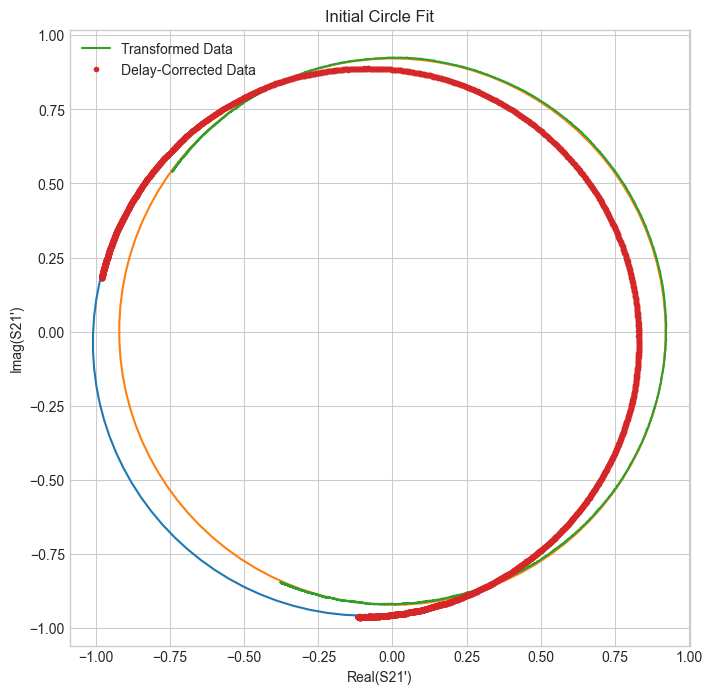

Initial Guesses (p0):
 fr = 6.6075e+09 Hz
 Qr = 50000.0
 theta0 = 0.0000 rad

Fit Results:
 fr = 6.6390e+09 ± 4.2e+04 Hz
 Qr = 185.4 ± 0.3
 theta0 = -0.4119 ± 0.0025 rad

Derived Parameters:
 Qc = 102.3
 phi0 = 2.3401 rad


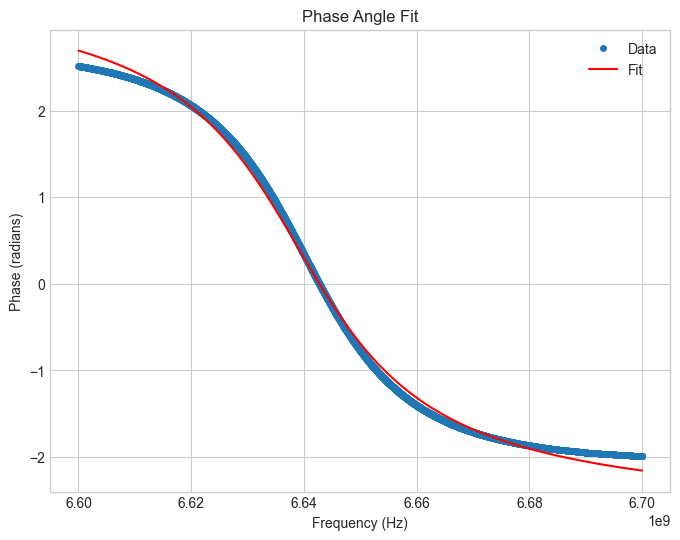

Fit successful! Resonance Frequency: 6.639022 +/- 0.000036 GHz


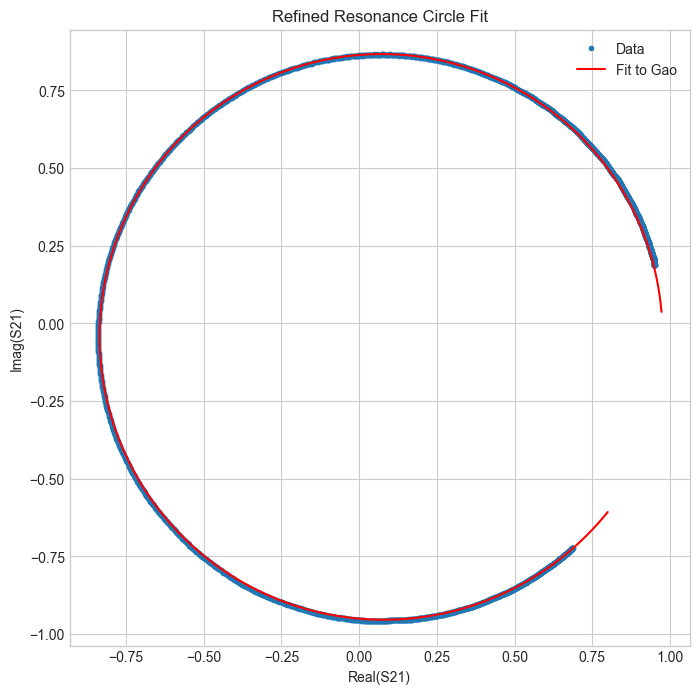

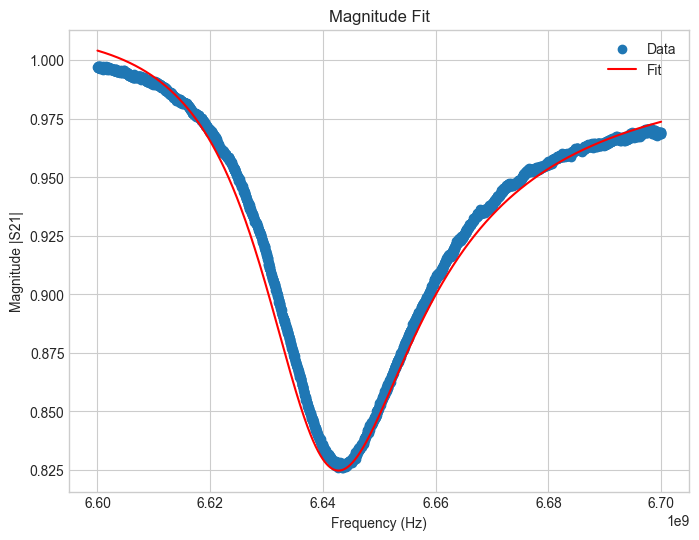

Number of complex points (n): 3885
Degrees of Freedom (2n - k): 7764
Estimated single-quadrature noise variance (sigma_0^2): 1.337e-07
Reduced Chi-Squared (chi_nu^2): 22025.3440


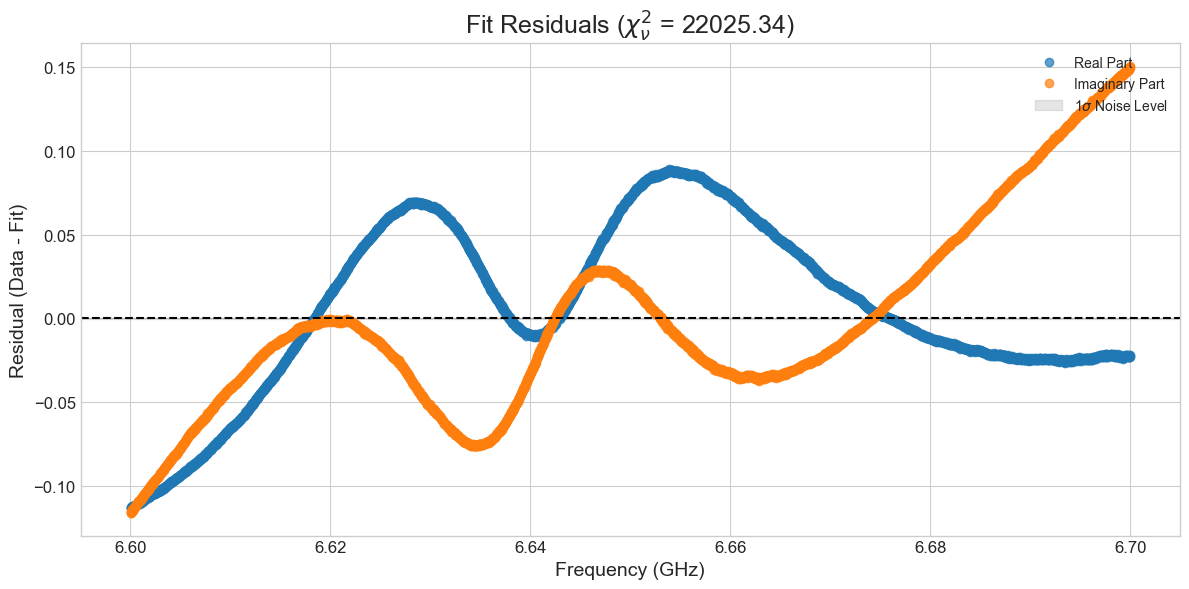

In [ ]:

f_min, f_max = 6.60e9, 6.7e9
s11 = 1.0*s11_real + 1.0j*s11_imag
mask = (freq >= f_min) & (freq <= f_max)
f_region = freq[mask]
s11_region = s11[mask]

a_fine, tau_fine, fr_fine, Qr_fine, Qc_fine, phi0_fine, chi2 = rf.refined_fit(f_region, s11_region, tau, plot_mode='all ', filename = "post_hole/post_hole")